# OpenAI Image & Vision

https://platform.openai.com/docs/guides/images-vision?format=url

In [3]:
%pip install dotenv openai

  Using cached dotenv-0.9.9-py2.py3-none-any.whl.metadata (279 bytes)
  Using cached python_dotenv-1.2.3-py3-none-any.whl.metadata (29 kB)
  Using cached httpx2-2.12.0-py3-none-any.whl.metadata (9.5 kB)
  Using cached pydantic-2.13.5-py3-none-any.whl.metadata (110 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached httpcore2-2.12.0-py3-none-any.whl.metadata (25 kB)
  Using cached truststore-0.10.4-py3-none-any.whl.metadata (4.4 kB)
  Using cached annotated_types-0.8.0-py3-none-any.whl.metadata (15 kB)
  Using cached typing_inspection-0.4.4-py3-none-any.whl.metadata (2.6 kB)
Using cached dotenv-0.9.9-py2.py3-none-any.whl (1.9 kB)
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   -------------------------- ------------- 1.3/2.0 MB 4.2 MB/s eta 0:00:01
   ------------------------------------ --- 1.8/2.0 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------

In [4]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [8]:
from openai import OpenAI
import base64 # 이미지 파일 저장용

client = OpenAI()

response = client.responses.create(
    model="gpt-6-astra",
    input="Generate an image of gray tabby cat hugging an otter with an orange scarf",
    tools=[{"type": "image_generation", "model": 'gpt-image-2.5-sunburst'}] ,
)

image_data = [ # base64 결과
    output.result
    for output in response.output
    if output.type == "image_generation_call" # 이미지 생성 결과만
]

# base64로 디코딩해 png로 저장
if image_data:
    image_base64 = image_data[0]
    with open("data/cat_and_otter.png", "wb") as f:
        f.write(base64.b64decode(image_base64))

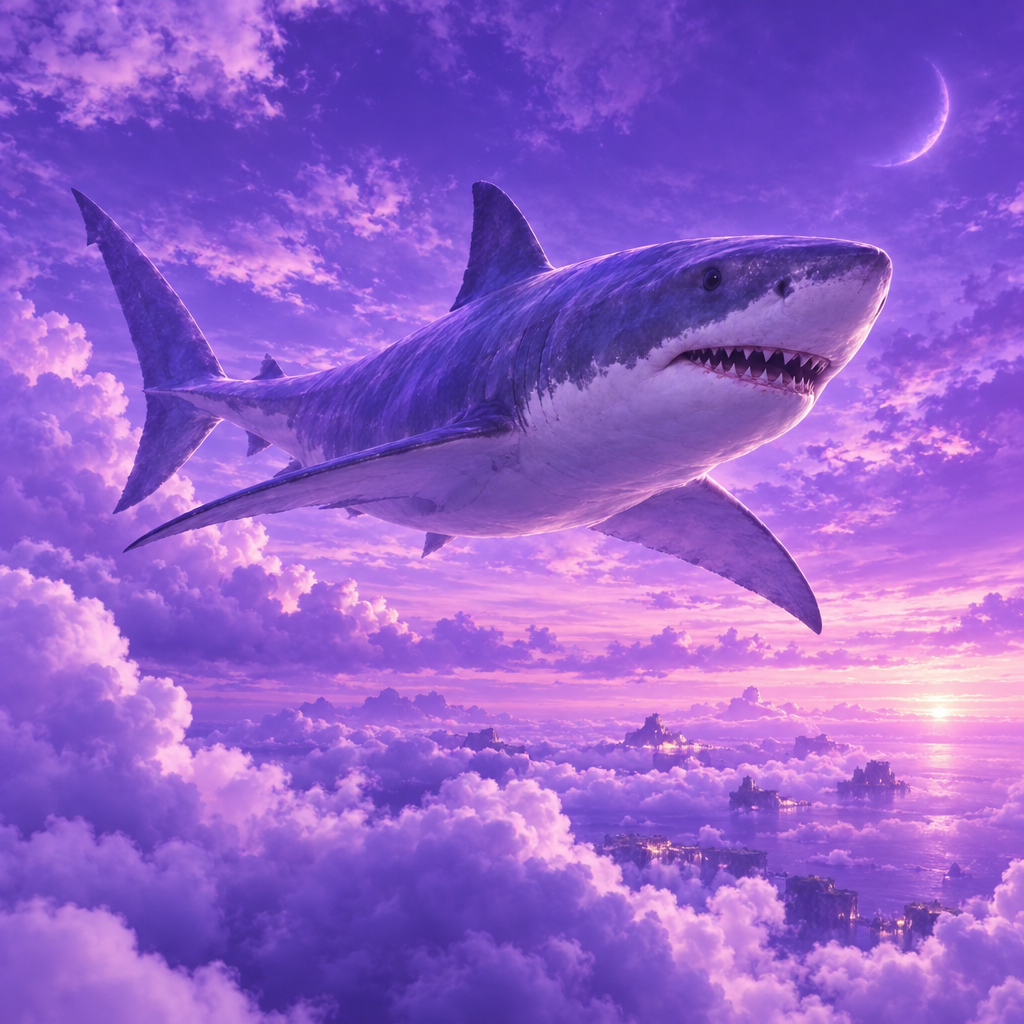

In [ ]:
from io import BytesIO # bytes 데이터를 파일처럼 조작 
from PIL import Image
from IPython.display import display # 노트북 환경에서 각종 출력

def generate_image(prompt: str):
    response = client.images.generate(
        model = 'gpt-image-2.5-flare',
        prompt = prompt,
        size='1024x1024',
        quality = 'high',
        output_format = 'png'
    )
    
    b64 = response.data[0].b64_json # 생성된 이미지의 base64 문자열
    img_bytes = base64.b64decode(b64)   # base64 이미지 -> bytes 로 변환
    
    img = Image.open(BytesIO(img_bytes)) # bytes 데이터를 이미지로 열기
    display(img) # 노트북 화면에 
    
generate_image('보라빛 하늘을 날아다니는 상어')

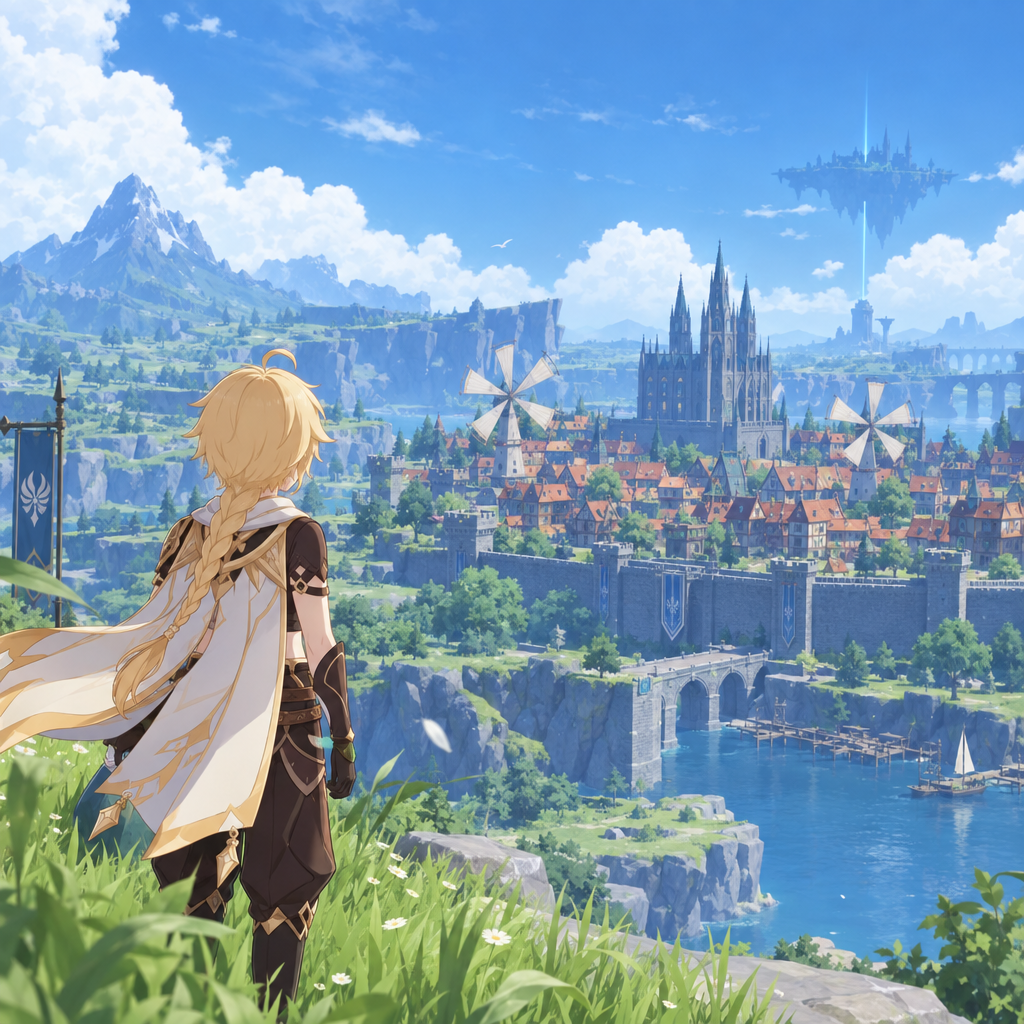

In [12]:
generate_image('게임 원신에서 몬드를 바라보는 여행자')